In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score
)

In [2]:

# Adjust the path for Kaggle vs local
CANDIDATE_PATHS = [
    "transactions 2.csv",                      
]

path = None
for p in CANDIDATE_PATHS:
    if os.path.exists(p):
        path = p
        break

assert path is not None, "transactions.csv not found. Please add it to input."
print("Using file:", path)

df = pd.read_csv(path)
print(df.shape)
df.head(3)


Using file: transactions 2.csv
(299695, 17)


,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0


In [3]:

# Parse datetime
df['transaction_time'] = pd.to_datetime(df['transaction_time'], errors='coerce')

# Basic sanity
print("Nulls per column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Derived helpers
df['country_match'] = (df['country'] == df['bin_country']).astype(int)
df['hour'] = df['transaction_time'].dt.hour
df['night_flag'] = df['hour'].isin([22,23,0,1,2,3,4,5]).astype(int)

# Summary
summary = {
    "rows": len(df),
    "unique_users": df['user_id'].nunique(),
    "fraud_tx": int(df['is_fraud'].sum()),
    "fraud_rate": df['is_fraud'].mean(),
    "country_match_rate": df['country_match'].mean(),
    "avg_tx_per_user": len(df) / df['user_id'].nunique()
}
summary


Nulls per column:
transaction_id          0
merchant_category       0
shipping_distance_km    0
transaction_time        0
three_ds_flag           0
cvv_result              0
avs_match               0
promo_used              0
channel                 0
user_id                 0
dtype: int64


{'rows': 299695,
 'unique_users': 6000,
 'fraud_tx': 6612,
 'fraud_rate': np.float64(0.02206243013730626),
 'country_match_rate': np.float64(0.9208194998248219),
 'avg_tx_per_user': 49.94916666666666}

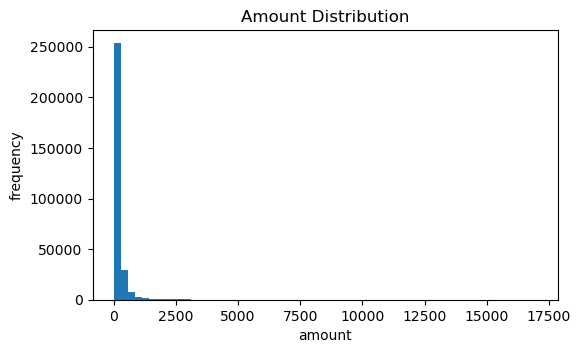

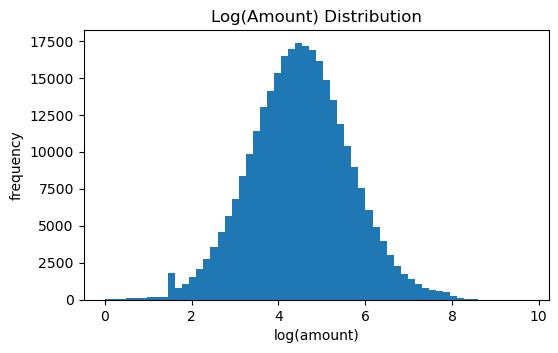

{'amount_mean': 177.16527856654264, 'amount_std': 306.9265069627889, 'log_amount_mean': 4.499736836509297, 'log_amount_std': 1.1526799500279332}


In [4]:

# Positive amounts only
amount = df['amount'].astype(float)
amount_pos = amount[amount > 0]
log_amount = np.log(amount_pos)

fig = plt.figure(figsize=(6,3.5))
plt.hist(amount_pos, bins=60)
plt.title('Amount Distribution')
plt.xlabel('amount')
plt.ylabel('frequency')
plt.show()

fig = plt.figure(figsize=(6,3.5))
plt.hist(log_amount, bins=60)
plt.title('Log(Amount) Distribution')
plt.xlabel('log(amount)')
plt.ylabel('frequency')
plt.show()

print({
    "amount_mean": float(amount_pos.mean()),
    "amount_std": float(amount_pos.std(ddof=1)),
    "log_amount_mean": float(log_amount.mean()),
    "log_amount_std": float(log_amount.std(ddof=1)),
})



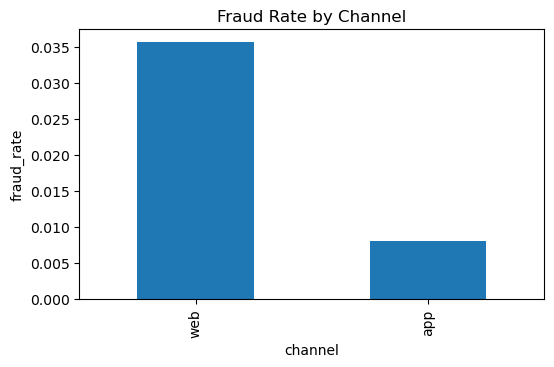

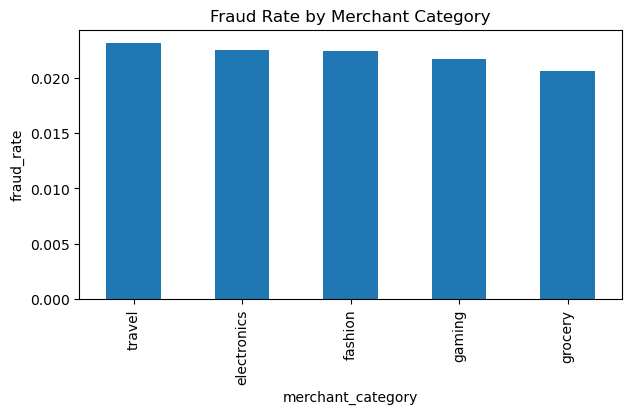

(channel
 web    0.035644
 app    0.008042
 Name: is_fraud, dtype: float64,
 merchant_category
 travel         0.023163
 electronics    0.022534
 fashion        0.022408
 gaming         0.021641
 grocery        0.020563
 Name: is_fraud, dtype: float64)

In [5]:

fraud_by_channel = df.groupby('channel')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_category = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False)

fig = plt.figure(figsize=(6,3.5))
fraud_by_channel.plot(kind='bar')
plt.title('Fraud Rate by Channel')
plt.ylabel('fraud_rate')
plt.show()

fig = plt.figure(figsize=(7,3.5))
fraud_by_category.plot(kind='bar')
plt.title('Fraud Rate by Merchant Category')
plt.ylabel('fraud_rate')
plt.show()

fraud_by_channel, fraud_by_category


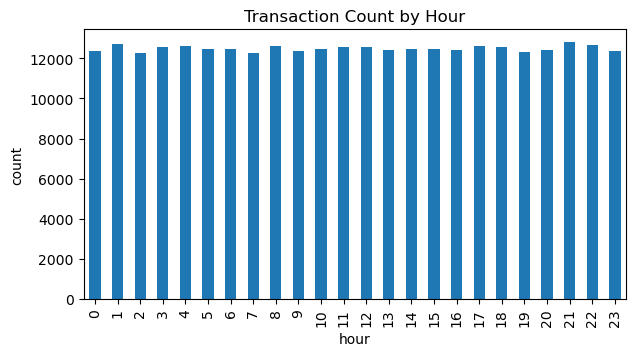

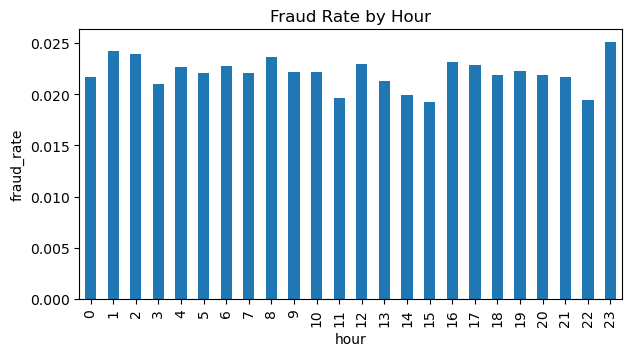

hour
23    0.025071
1     0.024208
2     0.023928
8     0.023670
16    0.023121
Name: is_fraud, dtype: float64

In [6]:

fraud_by_hour = df.groupby('hour')['is_fraud'].mean()
tx_by_hour = df.groupby('hour')['transaction_id'].count()

fig = plt.figure(figsize=(7,3.5))
tx_by_hour.plot(kind='bar')
plt.title('Transaction Count by Hour')
plt.ylabel('count')
plt.show()

fig = plt.figure(figsize=(7,3.5))
fraud_by_hour.plot(kind='bar')
plt.title('Fraud Rate by Hour')
plt.ylabel('fraud_rate')
plt.show()

fraud_by_hour.sort_values(ascending=False).head(5)


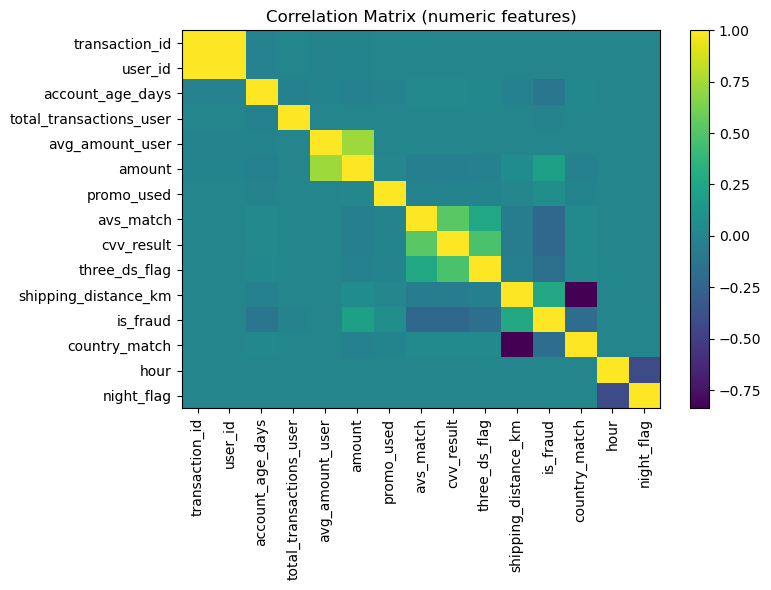

,is_fraud
is_fraud,1.000000
shipping_distance_km,0.270004
amount,0.202499
promo_used,0.067351
night_flag,0.002114
avg_amount_user,-0.001236
hour,-0.001911
user_id,-0.005294
transaction_id,-0.005295
total_transactions_user,-0.017093


In [7]:

# Numeric-only correlation
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig = plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title('Correlation Matrix (numeric features)')
plt.tight_layout()
plt.show()

corr.loc[['is_fraud'], :].T.sort_values('is_fraud', ascending=False).head(10)


In [8]:
# Optional: prepare features for modeling (no training here to keep it EDA-focused)

drop_cols = ['is_fraud','transaction_id','transaction_time']
X = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number]).copy()
y = df['is_fraud'].astype(int)

# First split off test (20%), then split remaining into train (75%) / val (25%) → 60/20/20 overall
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("Train size:", X_train.shape, " Fraud rate:", y_train.mean())
print("Val size:  ", X_val.shape,   " Fraud rate:", y_val.mean())
print("Test size: ", X_test.shape,  " Fraud rate:", y_test.mean())

Train size: (179817, 13)  Fraud rate: 0.022066879104867727
Val size:   (59939, 13)  Fraud rate: 0.022055756685964063
Test size:  (59939, 13)  Fraud rate: 0.022055756685964063


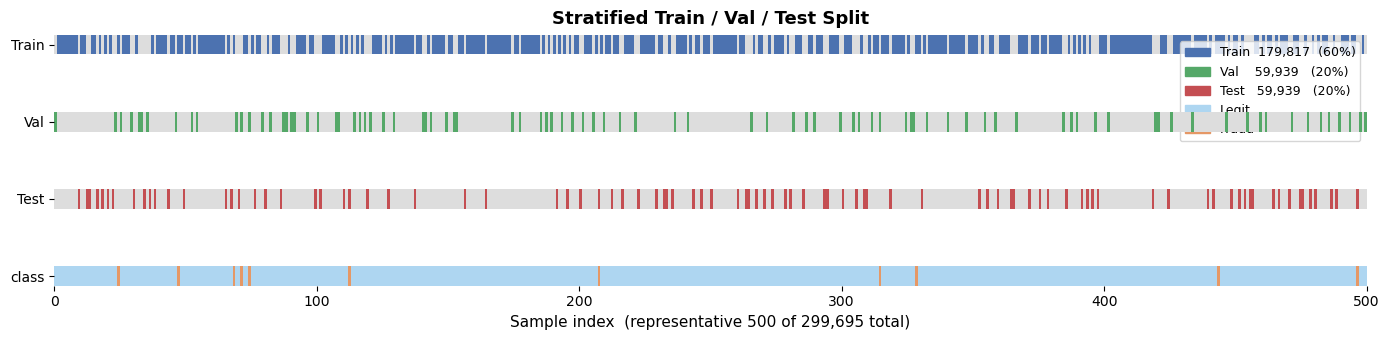

In [9]:
# ── Stratified Split Visualization ───────────────────────────────────────────
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

N_DISPLAY = 500   # representative samples to plot

# Sample evenly across the sorted index
all_idx   = np.array(sorted(X.index))
disp_idx  = all_idx[np.linspace(0, len(all_idx) - 1, N_DISPLAY, dtype=int)]

train_set = set(X_train.index)
val_set   = set(X_val.index)

split_arr = np.array([0 if i in train_set else (1 if i in val_set else 2) for i in disp_idx])
class_arr = y.loc[disp_idx].values

TRAIN_C = '#4C72B0';  VAL_C = '#55A868';  TEST_C = '#C44E52'
GRAY    = '#DDDDDD';  LEGIT_C = '#AED6F1'; FRAUD_C = '#E59866'

def make_row(mask, in_hex, out_hex=GRAY):
    in_rgb  = np.array(mcolors.to_rgb(in_hex))
    out_rgb = np.array(mcolors.to_rgb(out_hex))
    return np.where(mask[:, None], in_rgb, out_rgb)[np.newaxis]

row_data = [
    ('Train', make_row(split_arr == 0, TRAIN_C)),
    ('Val',   make_row(split_arr == 1, VAL_C)),
    ('Test',  make_row(split_arr == 2, TEST_C)),
    ('class', make_row(class_arr  == 1, FRAUD_C, LEGIT_C)),
]

fig, axes = plt.subplots(len(row_data), 1, figsize=(14, 3.5), sharex=True)
fig.subplots_adjust(hspace=0.08)

for ax, (label, img) in zip(axes, row_data):
    ax.imshow(img, aspect='auto', extent=[0, N_DISPLAY, -0.5, 0.5], interpolation='nearest')
    ax.set_yticks([0])
    ax.set_yticklabels([label], fontsize=10)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[-1].tick_params(axis='x', bottom=True, labelbottom=True)
axes[-1].set_xlabel(f'Sample index  (representative {N_DISPLAY} of {len(X):,} total)', fontsize=11)
axes[0].set_title('Stratified Train / Val / Test Split', fontsize=13, fontweight='bold', pad=8)

legend_handles = [
    mpatches.Patch(color=TRAIN_C, label=f'Train  {len(X_train):,}  ({len(X_train)/len(X):.0%})'),
    mpatches.Patch(color=VAL_C,   label=f'Val    {len(X_val):,}   ({len(X_val)/len(X):.0%})'),
    mpatches.Patch(color=TEST_C,  label=f'Test   {len(X_test):,}   ({len(X_test)/len(X):.0%})'),
    mpatches.Patch(color=LEGIT_C, label='Legit'),
    mpatches.Patch(color=FRAUD_C, label='Fraud'),
]
axes[0].legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(1.0, 1.0), fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

In [10]:
# ── Step 1: Feature Scaling ──────────────────────────────────────────────────
# Fit ONLY on train to prevent data leakage, then transform val & test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled ✓")
print(f"  Train shape : {X_train_scaled.shape}")
print(f"  Val shape   : {X_val_scaled.shape}")
print(f"  Test shape  : {X_test_scaled.shape}")
print(f"\nFeature list : {list(X_train.columns)}")

Features scaled ✓
  Train shape : (179817, 13)
  Val shape   : (59939, 13)
  Test shape  : (59939, 13)

Feature list : ['user_id', 'account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'country_match', 'hour', 'night_flag']


In [11]:
# ── Step 2: Train Baseline — Logistic Regression ─────────────────────────────
# class_weight='balanced' compensates for 2.2% fraud without SMOTE (Week 2)

lr_baseline = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_baseline.fit(X_train_scaled, y_train)

print("Logistic Regression (baseline) trained ✓")
print(f"  Iterations ran : {lr_baseline.n_iter_[0]}")
print(f"  Classes        : {lr_baseline.classes_}")

Logistic Regression (baseline) trained ✓
  Iterations ran : 13
  Classes        : [0 1]


In [12]:
# ── Step 3: Evaluate on Validation Set ───────────────────────────────────────

y_val_pred  = lr_baseline.predict(X_val_scaled)
y_val_proba = lr_baseline.predict_proba(X_val_scaled)[:, 1]

print("=" * 50)
print("  Validation Set — Classification Report")
print("=" * 50)
print(classification_report(y_val, y_val_pred, target_names=['Legit', 'Fraud'], digits=4))
print(f"ROC-AUC Score      : {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"Avg Precision Score: {average_precision_score(y_val, y_val_proba):.4f}")

  Validation Set — Classification Report
              precision    recall  f1-score   support

       Legit     0.9958    0.8818    0.9353     58617
       Fraud     0.1372    0.8336    0.2356      1322

    accuracy                         0.8807     59939
   macro avg     0.5665    0.8577    0.5855     59939
weighted avg     0.9768    0.8807    0.9199     59939

ROC-AUC Score      : 0.9292
Avg Precision Score: 0.5615


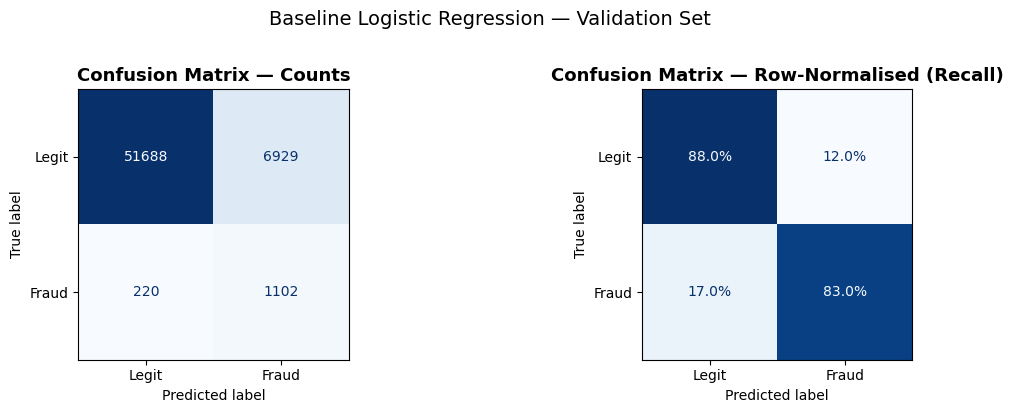

True  Negatives (Legit   → Legit ) : 51,688
False Positives (Legit   → Fraud ) : 6,929
False Negatives (Fraud   → Legit ) : 220  ← missed frauds
True  Positives (Fraud   → Fraud ) : 1,102  ← caught frauds


In [13]:
# ── Step 4: Confusion Matrix ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold')

# Row-normalised (recall per class)
cm_norm = confusion_matrix(y_val, y_val_pred, normalize='true')
disp = ConfusionMatrixDisplay(cm_norm, display_labels=['Legit', 'Fraud'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
for text in disp.text_.ravel():           # format as %
    text.set_text(f"{float(text.get_text()):.1%}")
axes[1].set_title('Confusion Matrix — Row-Normalised (Recall)', fontsize=13, fontweight='bold')

plt.suptitle('Baseline Logistic Regression — Validation Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (Legit   → Legit ) : {tn:,}")
print(f"False Positives (Legit   → Fraud ) : {fp:,}")
print(f"False Negatives (Fraud   → Legit ) : {fn:,}  ← missed frauds")
print(f"True  Positives (Fraud   → Fraud ) : {tp:,}  ← caught frauds")

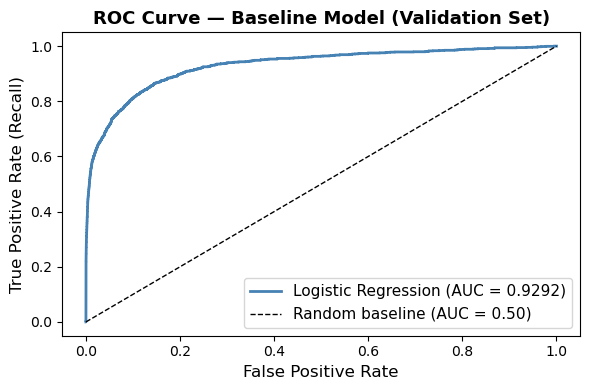

  Baseline Performance Summary (Validation Set)


,Accuracy,Precision(Fraud),Recall(Fraud),F1(Fraud),ROC-AUC,Avg Precision
Model,,,,,,
Logistic Regression (baseline),0.8807,0.1372,0.8336,0.2356,0.9292,0.5615


In [14]:
# ── Step 5: ROC Curve + Baseline Summary Table ────────────────────────────────

fpr, tpr, _ = roc_curve(y_val, y_val_proba)
auc = roc_auc_score(y_val, y_val_proba)

fig = plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — Baseline Model (Validation Set)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary table — benchmark for all future models ──────────────────────────
baseline_summary = pd.DataFrame([{
    'Model'            : 'Logistic Regression (baseline)',
    'Accuracy'         : round(accuracy_score(y_val, y_val_pred), 4),
    'Precision(Fraud)' : round(precision_score(y_val, y_val_pred), 4),
    'Recall(Fraud)'    : round(recall_score(y_val, y_val_pred), 4),
    'F1(Fraud)'        : round(f1_score(y_val, y_val_pred), 4),
    'ROC-AUC'          : round(roc_auc_score(y_val, y_val_proba), 4),
    'Avg Precision'    : round(average_precision_score(y_val, y_val_proba), 4),
}]).set_index('Model')

print("=" * 60)
print("  Baseline Performance Summary (Validation Set)")
print("=" * 60)
baseline_summary

In [15]:
# ── Step 6: Seller-Level Risk Aggregation ─────────────────────────────────────
# Uses the validation set predictions from Logistic Regression baseline
# In production this would run on incoming transactions in real time

import pandas as pd
import numpy as np

# ── 6a: Attach predicted probabilities back to validation rows ────────────────
# X_val still has the original index from the full dataframe
val_df = X_val.copy()
val_df['is_fraud_actual']    = y_val.values
val_df['fraud_prob']         = y_val_proba          # already computed in Step 3
val_df['predicted_fraud']    = y_val_pred            # already computed in Step 3

# ── 6b: AVG_RISK_SCORE per user ───────────────────────────────────────────────
# Rolling mean of predicted fraud probability per user
# Represents: how risky is this seller on average across all their transactions?

avg_risk = (
    val_df.groupby('user_id')['fraud_prob']
    .mean()
    .rename('avg_risk_score')
    .round(4)
)

# ── 6c: HIGH_RISK_FRACTION per user ──────────────────────────────────────────
# Fraction of transactions where predicted probability exceeds threshold (0.3)
# Threshold of 0.3 is intentionally lower than 0.5 to be conservative

RISK_THRESHOLD = 0.3

high_risk_fraction = (
    val_df.groupby('user_id')['fraud_prob']
    .apply(lambda x: (x >= RISK_THRESHOLD).mean())
    .rename('high_risk_fraction')
    .round(4)
)

# ── 6d: RISK_TREND_SLOPE per user ─────────────────────────────────────────────
# Linear slope of fraud_prob over transaction sequence per user
# Positive slope = fraud risk is increasing over time (escalating behavior)
# Negative slope = risk is decreasing
# Requires at least 2 transactions per user to compute

from numpy.polynomial.polynomial import polyfit

def compute_slope(probs):
    if len(probs) < 2:
        return 0.0
    x = np.arange(len(probs))
    # polyfit returns [intercept, slope] for degree=1
    slope = polyfit(x, probs.values, 1)[1]
    return round(float(slope), 6)

risk_trend_slope = (
    val_df.groupby('user_id')['fraud_prob']
    .apply(compute_slope)
    .rename('risk_trend_slope')
)

# ── 6e: Combine into Seller Risk Profile ──────────────────────────────────────
seller_risk_profile = pd.concat(
    [avg_risk, high_risk_fraction, risk_trend_slope],
    axis=1
)

# Add transaction count per user for context
seller_risk_profile['tx_count'] = (
    val_df.groupby('user_id')['fraud_prob'].count()
)

# Add actual fraud rate per user (ground truth — for validation only)
seller_risk_profile['actual_fraud_rate'] = (
    val_df.groupby('user_id')['is_fraud_actual'].mean().round(4)
)

print(f"Seller risk profiles computed for {len(seller_risk_profile)} users")
print(seller_risk_profile.describe())
seller_risk_profile.head(10)

Seller risk profiles computed for 6000 users
       avg_risk_score  high_risk_fraction  risk_trend_slope     tx_count  \
count     6000.000000         6000.000000       6000.000000  6000.000000   
mean         0.220088            0.227912         -0.000355     9.989833   
std          0.120219            0.179204          0.038102     3.073104   
min          0.022300            0.000000         -0.370687     1.000000   
25%          0.130175            0.100000         -0.014290     8.000000   
50%          0.200400            0.200000         -0.000168    10.000000   
75%          0.285650            0.333300          0.013719    12.000000   
max          0.947700            1.000000          0.478820    21.000000   

       actual_fraud_rate  
count        6000.000000  
mean            0.022413  
std             0.084013  
min             0.000000  
25%             0.000000  
50%             0.000000  
75%             0.000000  
max             1.000000  


,avg_risk_score,high_risk_fraction,risk_trend_slope,tx_count,actual_fraud_rate
user_id,,,,,
1,0.3372,0.3000,0.011490,10,0.0
2,0.0711,0.0000,-0.002644,9,0.0
3,0.1283,0.0000,-0.005344,7,0.0
4,0.2199,0.2000,-0.006846,10,0.0
5,0.4468,0.5000,0.212227,4,0.0
6,0.2072,0.1111,-0.047024,9,0.0
7,0.3281,0.5000,-0.013000,12,0.0
8,0.1603,0.0000,0.015567,6,0.0
9,0.2120,0.1667,0.015354,12,0.0


In [16]:
# ── Step 7: Flag and Rank High-Risk Sellers ───────────────────────────────────
# A seller is HIGH RISK if they meet ANY of these criteria:
#   - avg_risk_score    >= 0.40  (consistently elevated probability)
#   - high_risk_fraction >= 0.20  (20%+ of their transactions are suspicious)
#   - risk_trend_slope  >= 0.01  (fraud risk is actively accelerating)

HIGH_RISK_AVG       = 0.40
HIGH_RISK_FRACTION  = 0.20
HIGH_RISK_SLOPE     = 0.01

seller_risk_profile['is_high_risk'] = (
    (seller_risk_profile['avg_risk_score']    >= HIGH_RISK_AVG)    |
    (seller_risk_profile['high_risk_fraction'] >= HIGH_RISK_FRACTION) |
    (seller_risk_profile['risk_trend_slope']  >= HIGH_RISK_SLOPE)
)

high_risk_sellers = (
    seller_risk_profile[seller_risk_profile['is_high_risk']]
    .sort_values('avg_risk_score', ascending=False)
)

print(f"Total sellers in validation : {len(seller_risk_profile)}")
print(f"High-risk sellers flagged   : {len(high_risk_sellers)}")
print(f"Flag rate                   : {len(high_risk_sellers)/len(seller_risk_profile):.2%}")
print()
print("Top 10 Highest Risk Sellers:")
print(high_risk_sellers.head(10).to_string())

Total sellers in validation : 6000
High-risk sellers flagged   : 3823
Flag rate                   : 63.72%

Top 10 Highest Risk Sellers:
         avg_risk_score  high_risk_fraction  risk_trend_slope  tx_count  actual_fraud_rate  is_high_risk
user_id                                                                                                 
4392             0.9477              1.0000          0.005209         5             1.0000          True
2956             0.9320              1.0000         -0.023008         7             0.8571          True
4271             0.8899              1.0000         -0.004452         7             0.4286          True
3087             0.8207              1.0000         -0.168045         4             0.7500          True
1724             0.8184              0.9000         -0.056282        10             0.7000          True
4444             0.8063              1.0000          0.001337        11             0.6364          True
2303             0.8052

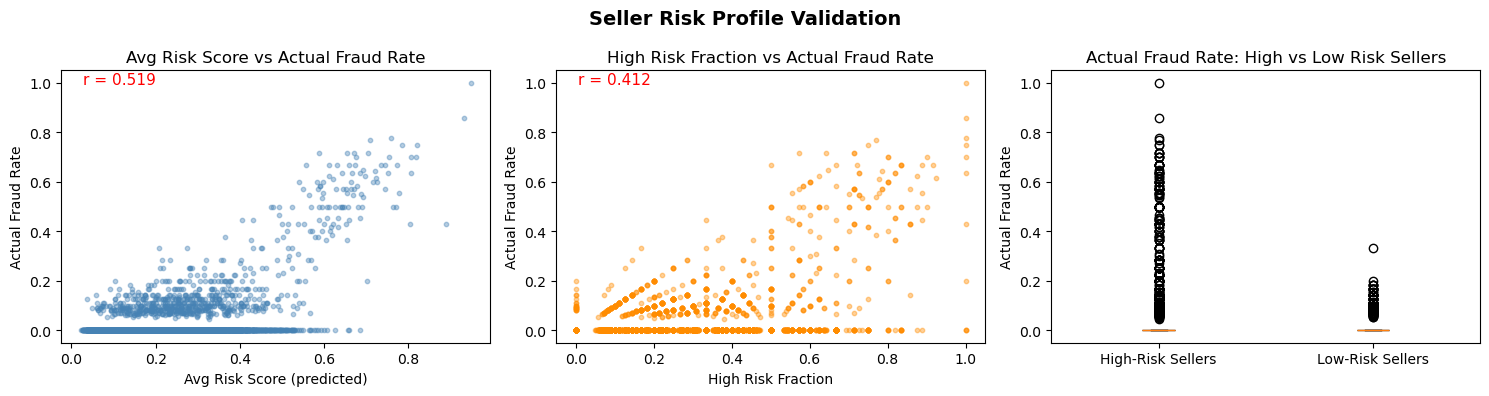

Correlation with actual fraud rate:
  avg_risk_score    : 0.5195
  high_risk_fraction: 0.4117


In [17]:
# ── Step 8: Validate Seller Risk Scores Against Actual Fraud Rates ────────────
# This is how we prove the seller layer is meaningful —
# high-risk sellers should have significantly higher actual fraud rates

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: avg_risk_score vs actual_fraud_rate
axes[0].scatter(
    seller_risk_profile['avg_risk_score'],
    seller_risk_profile['actual_fraud_rate'],
    alpha=0.4, s=10, color='steelblue'
)
axes[0].set_xlabel('Avg Risk Score (predicted)')
axes[0].set_ylabel('Actual Fraud Rate')
axes[0].set_title('Avg Risk Score vs Actual Fraud Rate')

corr0 = seller_risk_profile[['avg_risk_score','actual_fraud_rate']].corr().iloc[0,1]
axes[0].text(0.05, 0.95, f'r = {corr0:.3f}',
             transform=axes[0].transAxes, fontsize=11, color='red')

# Plot 2: high_risk_fraction vs actual_fraud_rate
axes[1].scatter(
    seller_risk_profile['high_risk_fraction'],
    seller_risk_profile['actual_fraud_rate'],
    alpha=0.4, s=10, color='darkorange'
)
axes[1].set_xlabel('High Risk Fraction')
axes[1].set_ylabel('Actual Fraud Rate')
axes[1].set_title('High Risk Fraction vs Actual Fraud Rate')

corr1 = seller_risk_profile[['high_risk_fraction','actual_fraud_rate']].corr().iloc[0,1]
axes[1].text(0.05, 0.95, f'r = {corr1:.3f}',
             transform=axes[1].transAxes, fontsize=11, color='red')

# Plot 3: High-risk vs low-risk seller actual fraud rate distribution
axes[2].boxplot(
    [
        seller_risk_profile[seller_risk_profile['is_high_risk']]['actual_fraud_rate'],
        seller_risk_profile[~seller_risk_profile['is_high_risk']]['actual_fraud_rate']
    ],
    tick_labels=['High-Risk Sellers', 'Low-Risk Sellers'],
    patch_artist=True,
    boxprops=dict(facecolor='salmon')
)
axes[2].set_ylabel('Actual Fraud Rate')
axes[2].set_title('Actual Fraud Rate: High vs Low Risk Sellers')

plt.suptitle('Seller Risk Profile Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation summary
print("Correlation with actual fraud rate:")
print(f"  avg_risk_score    : {corr0:.4f}")
print(f"  high_risk_fraction: {corr1:.4f}")

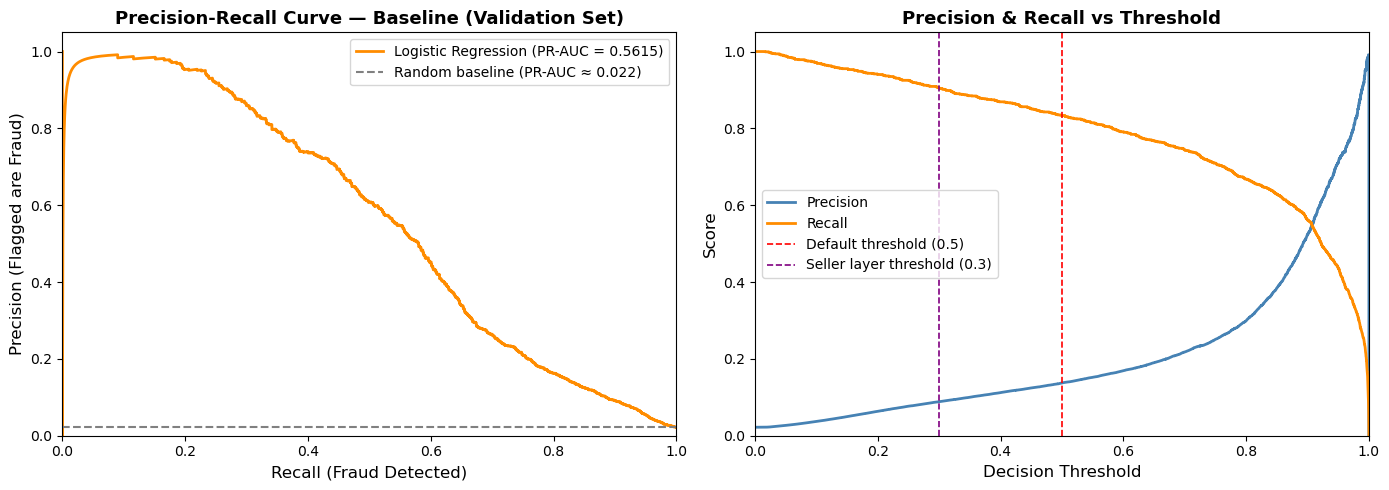

PR-AUC  : 0.5615  (random baseline ≈ 0.0221)
ROC-AUC : 0.9292  (random baseline = 0.5000)

Note: PR-AUC is the primary metric for imbalanced fraud detection.
      Our model is 25.5x better than random on PR-AUC.


In [18]:
# ── PR-AUC Curve (Precision-Recall) ──────────────────────────────────────────
# More informative than ROC-AUC for imbalanced datasets like ours (2.2% fraud)
# A random classifier scores equal to the fraud prevalence (~0.022), not 0.50

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, y_val_proba)
pr_auc = average_precision_score(y_val, y_val_proba)
no_skill = y_val.mean()   # random baseline = fraud prevalence

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Full PR Curve ───────────────────────────────────────────────────────
axes[0].plot(recall_vals, precision_vals, color='darkorange', lw=2,
             label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')
axes[0].axhline(y=no_skill, color='gray', linestyle='--', lw=1.5,
                label=f'Random baseline (PR-AUC ≈ {no_skill:.3f})')
axes[0].set_xlabel('Recall (Fraud Detected)', fontsize=12)
axes[0].set_ylabel('Precision (Flagged are Fraud)', fontsize=12)
axes[0].set_title('Precision-Recall Curve — Baseline (Validation Set)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1]);  axes[0].set_ylim([0, 1.05])

# ── Right: Precision & Recall vs Threshold ────────────────────────────────────
axes[1].plot(thresholds, precision_vals[:-1], color='steelblue', lw=2, label='Precision')
axes[1].plot(thresholds, recall_vals[:-1],    color='darkorange', lw=2, label='Recall')

# Mark the default 0.5 threshold
axes[1].axvline(x=0.5, color='red', linestyle='--', lw=1.2, label='Default threshold (0.5)')
axes[1].axvline(x=0.3, color='purple', linestyle='--', lw=1.2, label='Seller layer threshold (0.3)')

axes[1].set_xlabel('Decision Threshold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision & Recall vs Threshold', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1]);  axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f"PR-AUC  : {pr_auc:.4f}  (random baseline ≈ {no_skill:.4f})")
print(f"ROC-AUC : {roc_auc_score(y_val, y_val_proba):.4f}  (random baseline = 0.5000)")
print()
print("Note: PR-AUC is the primary metric for imbalanced fraud detection.")
print(f"      Our model is {pr_auc/no_skill:.1f}x better than random on PR-AUC.")

## Week 2 — Feature Engineering & Imbalance Handling

In [19]:
import subprocess, sys
for pkg in ['imbalanced-learn', 'xgboost', 'shap', 'lime']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print(f"  {pkg} ✓")
print("All dependencies ready.")

  imbalanced-learn ✓
  xgboost ✓
  shap ✓
  lime ✓
All dependencies ready.


In [20]:
# ── Week 2a: Enhanced Feature Engineering ─────────────────────────────────────
# Add log_amount and amount_ratio, then rebuild X / splits / scaler from scratch

df['log_amount']   = np.log1p(df['amount'])                         # log1p handles 0 safely
df['amount_ratio'] = df['amount'] / (df['avg_amount_user'] + 1e-6)  # txn vs user's usual spend

drop_cols = ['is_fraud', 'transaction_id', 'transaction_time']
X = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number]).copy()
y = df['is_fraud'].astype(int)

# Re-split with same seed → fully reproducible
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2,  stratify=y,      random_state=42)
X_train, X_val,  y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Re-scale (fit on train only)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

FEATURE_NAMES = list(X_train.columns)
print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")
print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")

Features (15): ['user_id', 'account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'country_match', 'hour', 'night_flag', 'log_amount', 'amount_ratio']
Train : (179817, 15) | Val : (59939, 15) | Test : (59939, 15)


In [21]:
# ── Week 2b: Imbalance Strategy Comparison ────────────────────────────────────
from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler

smote           = SMOTE(random_state=42)
X_tr_smote, y_tr_smote = smote.fit_resample(X_train_scaled, y_train)

rus             = RandomUnderSampler(random_state=42)
X_tr_under, y_tr_under = rus.fit_resample(X_train_scaled, y_train)

print(f"Original    : {X_train_scaled.shape[0]:>7,} samples | fraud rate {y_train.mean():.4f}")
print(f"SMOTE       : {X_tr_smote.shape[0]:>7,} samples | fraud rate {y_tr_smote.mean():.4f}")
print(f"Undersample : {X_tr_under.shape[0]:>7,} samples | fraud rate {y_tr_under.mean():.4f}")

strategies = {
    'Class Weight': (X_train_scaled, y_train,   {'class_weight': 'balanced'}),
    'SMOTE':        (X_tr_smote,    y_tr_smote,  {}),
    'Undersample':  (X_tr_under,    y_tr_under,  {}),
}

imbalance_results = []
for name, (X_tr, y_tr, kw) in strategies.items():
    m   = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, **kw)
    m.fit(X_tr, y_tr)
    yp  = m.predict(X_val_scaled)
    ypr = m.predict_proba(X_val_scaled)[:, 1]
    imbalance_results.append({
        'Strategy':         name,
        'Recall(Fraud)':    round(recall_score(y_val, yp), 4),
        'Precision(Fraud)': round(precision_score(y_val, yp), 4),
        'F1(Fraud)':        round(f1_score(y_val, yp), 4),
        'ROC-AUC':          round(roc_auc_score(y_val, ypr), 4),
        'PR-AUC':           round(average_precision_score(y_val, ypr), 4),
    })

imbalance_df = pd.DataFrame(imbalance_results).set_index('Strategy')
print("\n=== Imbalance Strategy Comparison (LR, Validation Set) ===")
imbalance_df

Original    : 179,817 samples | fraud rate 0.0221
SMOTE       : 351,698 samples | fraud rate 0.5000
Undersample :   7,936 samples | fraud rate 0.5000

=== Imbalance Strategy Comparison (LR, Validation Set) ===


,Recall(Fraud),Precision(Fraud),F1(Fraud),ROC-AUC,PR-AUC
Strategy,,,,,
Class Weight,0.8487,0.1575,0.2656,0.9431,0.6214
SMOTE,0.8457,0.1583,0.2667,0.9425,0.6256
Undersample,0.8540,0.1559,0.2636,0.9430,0.6106


## Week 3 — Train All Model Families

In [22]:
# ── Week 3: Train All Model Families ──────────────────────────────────────────
from sklearn.neighbors   import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree        import DecisionTreeClassifier
from sklearn.ensemble    import RandomForestClassifier
from sklearn.svm         import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not found — skipping")

scale_pw = int((y_train == 0).sum() / (y_train == 1).sum())

model_zoo = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'k-NN (k=5)':          KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes':         GaussianNB(),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1),
    'Linear SVM':          CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)),
}
if HAS_XGB:
    model_zoo['XGBoost'] = XGBClassifier(
        scale_pos_weight=scale_pw, n_estimators=100,
        random_state=42, eval_metric='logloss', verbosity=0
    )

all_results    = []
trained_models = {}

for name, model in model_zoo.items():
    print(f"Training {name:25s}", end=' ... ')
    model.fit(X_train_scaled, y_train)
    yp  = model.predict(X_val_scaled)
    ypr = model.predict_proba(X_val_scaled)[:, 1]
    trained_models[name] = model
    row = {
        'Model':            name,
        'Precision(Fraud)': round(precision_score(y_val, yp), 4),
        'Recall(Fraud)':    round(recall_score(y_val, yp), 4),
        'F1(Fraud)':        round(f1_score(y_val, yp), 4),
        'ROC-AUC':          round(roc_auc_score(y_val, ypr), 4),
        'PR-AUC':           round(average_precision_score(y_val, ypr), 4),
    }
    all_results.append(row)
    print(f"F1={row['F1(Fraud)']:.4f}  PR-AUC={row['PR-AUC']:.4f}")

results_df = pd.DataFrame(all_results).set_index('Model').sort_values('PR-AUC', ascending=False)
print("\n=== All Models — Validation Set (sorted by PR-AUC) ===")
results_df

Training Logistic Regression       ... F1=0.2656  PR-AUC=0.6214
F1=0.6130  PR-AUC=0.5790           ... 
Training Naive Bayes               ... F1=0.3535  PR-AUC=0.4597
F1=0.4255  PR-AUC=0.8266           ... 
F1=0.8287  PR-AUC=0.8479           ... 
F1=0.5562  PR-AUC=0.6223           ... 
F1=0.6422  PR-AUC=0.8384           ... 

=== All Models — Validation Set (sorted by PR-AUC) ===


,Precision(Fraud),Recall(Fraud),F1(Fraud),ROC-AUC,PR-AUC
Model,,,,,
Random Forest,0.9583,0.7300,0.8287,0.9536,0.8479
XGBoost,0.5225,0.8328,0.6422,0.9615,0.8384
Decision Tree,0.2809,0.8775,0.4255,0.9410,0.8266
Linear SVM,0.8481,0.4138,0.5562,0.9431,0.6223
Logistic Regression,0.1575,0.8487,0.2656,0.9431,0.6214
k-NN (k=5),0.9279,0.4576,0.6130,0.8374,0.5790
Naive Bayes,0.2557,0.5726,0.3535,0.9242,0.4597


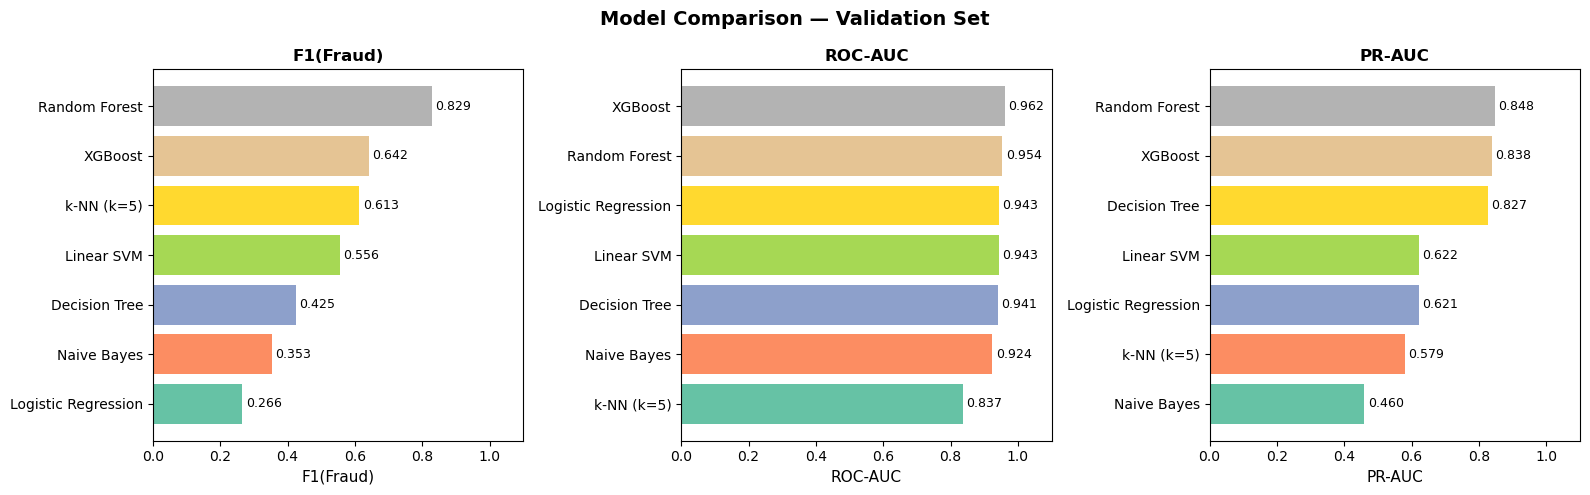

In [23]:
# ── Week 3: Model Comparison Chart ────────────────────────────────────────────
metrics   = ['F1(Fraud)', 'ROC-AUC', 'PR-AUC']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette   = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

for ax, metric in zip(axes, metrics):
    vals = results_df[metric].sort_values()
    bars = ax.barh(vals.index, vals.values, color=palette[:len(vals)])
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.1)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Week 4 — Hyperparameter Tuning & Cross-Validation

In [24]:
# ── Week 4a: Hyperparameter Tuning — Random Forest + XGBoost ──────────────────
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Random Forest ──────────────────────────────────────────────────────────────
rf_param_dist = {
    'n_estimators':      randint(100, 400),
    'max_depth':         [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.5],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_param_dist, n_iter=20, cv=cv5, scoring='average_precision',
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train_scaled, y_train)
best_rf  = rf_search.best_estimator_
yp_rf    = best_rf.predict(X_val_scaled)
ypr_rf   = best_rf.predict_proba(X_val_scaled)[:, 1]
print(f"RF  best params : {rf_search.best_params_}")
print(f"RF  CV PR-AUC   : {rf_search.best_score_:.4f}")
print(f"RF  Val → F1={f1_score(y_val,yp_rf):.4f}  PR-AUC={average_precision_score(y_val,ypr_rf):.4f}  ROC-AUC={roc_auc_score(y_val,ypr_rf):.4f}")

# ── XGBoost ────────────────────────────────────────────────────────────────────
if HAS_XGB:
    xgb_param_dist = {
        'n_estimators':     randint(100, 400),
        'max_depth':        randint(3, 10),
        'learning_rate':    [0.01, 0.05, 0.1, 0.2],
        'subsample':        [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': randint(1, 10),
    }
    xgb_search = RandomizedSearchCV(
        XGBClassifier(scale_pos_weight=scale_pw, random_state=42,
                      eval_metric='logloss', verbosity=0),
        xgb_param_dist, n_iter=20, cv=cv5, scoring='average_precision',
        random_state=42, n_jobs=-1, verbose=0
    )
    xgb_search.fit(X_train_scaled, y_train)
    best_xgb = xgb_search.best_estimator_
    yp_xgb   = best_xgb.predict(X_val_scaled)
    ypr_xgb  = best_xgb.predict_proba(X_val_scaled)[:, 1]
    print(f"\nXGB best params : {xgb_search.best_params_}")
    print(f"XGB CV PR-AUC   : {xgb_search.best_score_:.4f}")
    print(f"XGB Val → F1={f1_score(y_val,yp_xgb):.4f}  PR-AUC={average_precision_score(y_val,ypr_xgb):.4f}  ROC-AUC={roc_auc_score(y_val,ypr_xgb):.4f}")

RF  best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 11, 'n_estimators': 287}
RF  CV PR-AUC   : 0.8523
RF  Val → F1=0.8312  PR-AUC=0.8558  ROC-AUC=0.9658

XGB best params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 290, 'subsample': 0.8}
XGB CV PR-AUC   : 0.8507
XGB Val → F1=0.4500  PR-AUC=0.8572  ROC-AUC=0.9708


Best model selected: XGB (Tuned)
Running 5-Fold Stratified CV...

  PR-AUC  : 0.8507 ± 0.0166
  ROC-AUC : 0.9720 ± 0.0024
  F1      : 0.4651 ± 0.0088


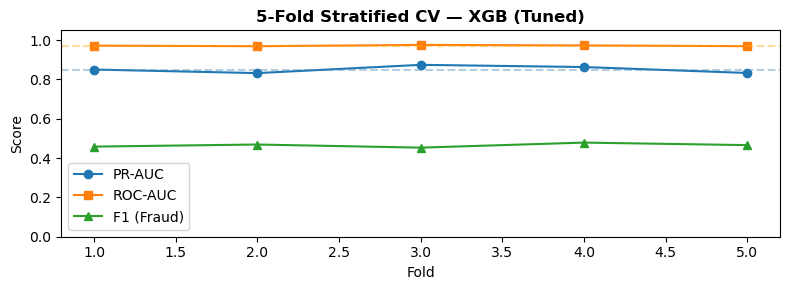

In [25]:
# ── Week 4b: Stratified K-Fold CV on Best Model ───────────────────────────────
from sklearn.model_selection import cross_validate

# Pick whichever of RF / XGB scored higher on val PR-AUC
if HAS_XGB and average_precision_score(y_val, ypr_xgb) > average_precision_score(y_val, ypr_rf):
    best_model      = best_xgb
    best_model_name = 'XGB (Tuned)'
else:
    best_model      = best_rf
    best_model_name = 'RF (Tuned)'

print(f"Best model selected: {best_model_name}")
print(f"Running 5-Fold Stratified CV...")

cv_scores = cross_validate(
    best_model, X_train_scaled, y_train,
    cv=cv5,
    scoring={'pr_auc': 'average_precision', 'roc_auc': 'roc_auc', 'f1': 'f1'},
    return_train_score=False, n_jobs=-1
)

print(f"\n  PR-AUC  : {cv_scores['test_pr_auc'].mean():.4f} ± {cv_scores['test_pr_auc'].std():.4f}")
print(f"  ROC-AUC : {cv_scores['test_roc_auc'].mean():.4f} ± {cv_scores['test_roc_auc'].std():.4f}")
print(f"  F1      : {cv_scores['test_f1'].mean():.4f} ± {cv_scores['test_f1'].std():.4f}")

fig, ax = plt.subplots(figsize=(8, 3))
folds = np.arange(1, 6)
ax.plot(folds, cv_scores['test_pr_auc'],  marker='o', label='PR-AUC')
ax.plot(folds, cv_scores['test_roc_auc'], marker='s', label='ROC-AUC')
ax.plot(folds, cv_scores['test_f1'],      marker='^', label='F1 (Fraud)')
ax.axhline(cv_scores['test_pr_auc'].mean(),  linestyle='--', alpha=0.4, color='steelblue')
ax.axhline(cv_scores['test_roc_auc'].mean(), linestyle='--', alpha=0.4, color='orange')
ax.set_xlabel('Fold'); ax.set_ylabel('Score')
ax.set_title(f'5-Fold Stratified CV — {best_model_name}', fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

## Week 5 — SHAP & LIME Interpretability

Computing SHAP values (may take ~30s)...


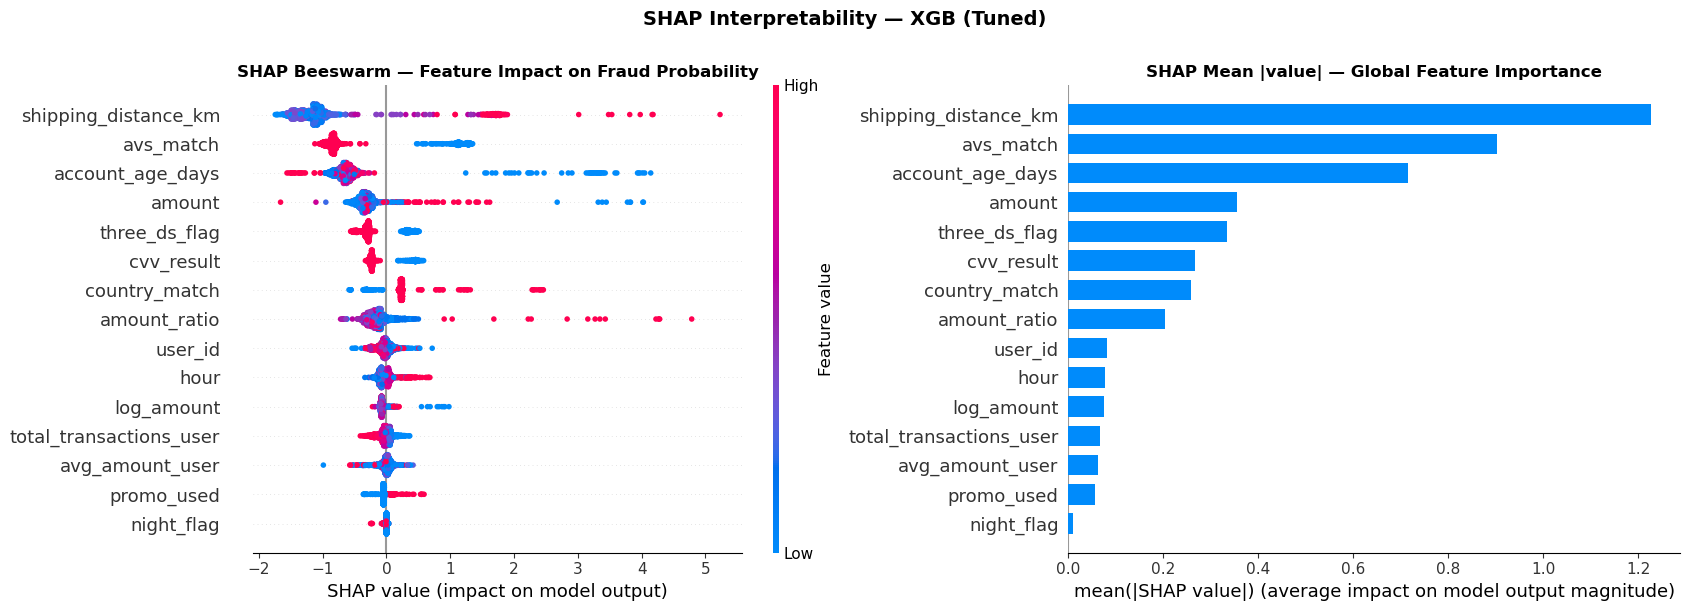

In [26]:
# ── Week 5a: SHAP — Global Feature Importance ─────────────────────────────────
import shap

print("Computing SHAP values (may take ~30s)...")
explainer  = shap.TreeExplainer(best_model)

rng        = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val_scaled), 2000, replace=False)
X_shap     = X_val_scaled[sample_idx]

shap_values = explainer.shap_values(X_shap)
# RF returns [class0_sv, class1_sv] — take fraud class
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

plt.sca(axes[0])
shap.summary_plot(sv, X_shap, feature_names=FEATURE_NAMES, show=False, plot_size=None)
axes[0].set_title('SHAP Beeswarm — Feature Impact on Fraud Probability',
                  fontsize=12, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(sv, X_shap, feature_names=FEATURE_NAMES,
                  plot_type='bar', show=False, plot_size=None)
axes[1].set_title('SHAP Mean |value| — Global Feature Importance',
                  fontsize=12, fontweight='bold')

plt.suptitle(f'SHAP Interpretability — {best_model_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Transaction #71  |  Predicted fraud prob: 0.9992  |  Actual label: 1


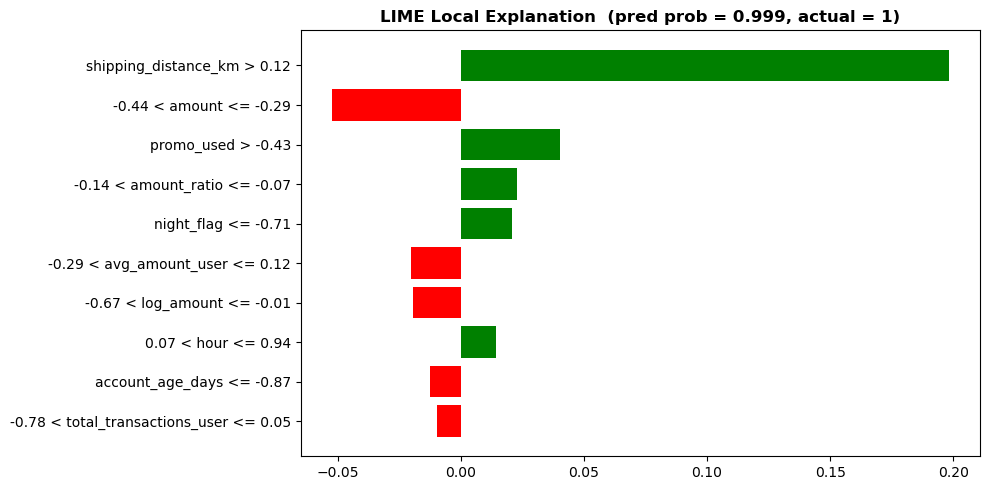

In [27]:
# ── Week 5b: LIME — Local Explanation for a High-Risk Transaction ─────────────
import lime, lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=FEATURE_NAMES,
    class_names=['Legit', 'Fraud'],
    mode='classification',
    random_state=42
)

# Find a high-confidence fraud transaction
best_proba    = best_model.predict_proba(X_val_scaled)[:, 1]
high_risk_idx = int(np.where(best_proba > 0.85)[0][0])
prob          = best_proba[high_risk_idx]
actual        = y_val.values[high_risk_idx]

print(f"Transaction #{high_risk_idx}  |  Predicted fraud prob: {prob:.4f}  |  Actual label: {actual}")

exp = lime_explainer.explain_instance(
    X_val_scaled[high_risk_idx],
    best_model.predict_proba,
    num_features=10,
    num_samples=500
)

fig = exp.as_pyplot_figure()
fig.set_size_inches(10, 5)
plt.title(f'LIME Local Explanation  (pred prob = {prob:.3f}, actual = {actual})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Week 6 — Calibration & Final Summary

/opt/anaconda3/lib/python3.13/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


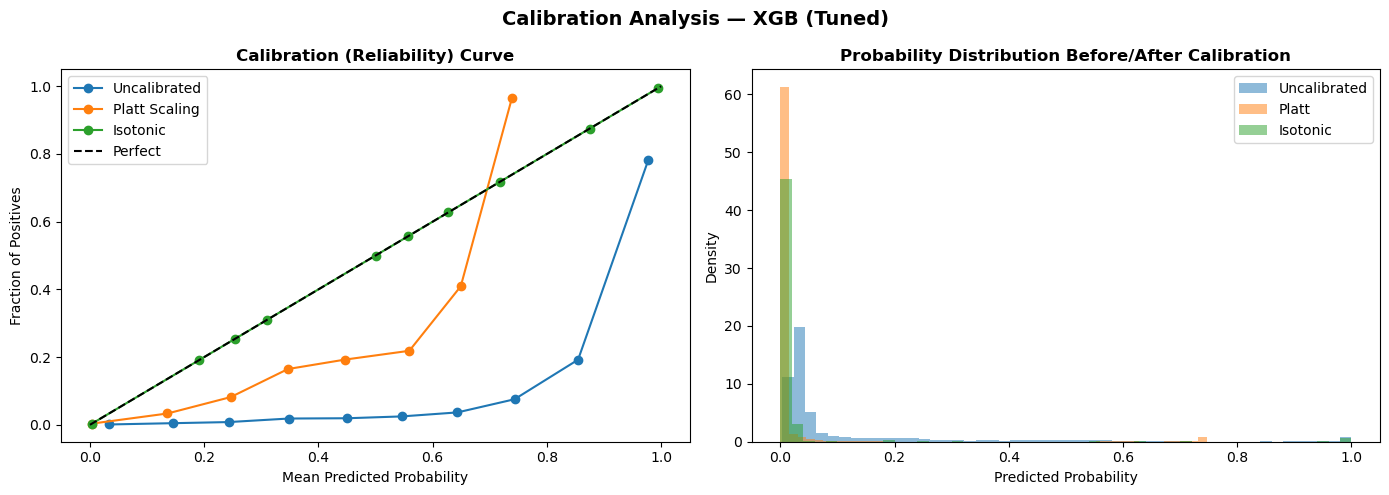

In [28]:
# ── Week 6a: Probability Calibration ─────────────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Calibrate on val set (prefit). Production would use a dedicated holdout.
platt    = CalibratedClassifierCV(best_model, cv='prefit', method='sigmoid')
isotonic = CalibratedClassifierCV(best_model, cv='prefit', method='isotonic')
platt.fit(X_val_scaled, y_val)
isotonic.fit(X_val_scaled, y_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: reliability / calibration curves
for label, model in [('Uncalibrated', best_model), ('Platt Scaling', platt), ('Isotonic', isotonic)]:
    prob = model.predict_proba(X_val_scaled)[:, 1]
    fp, mp = calibration_curve(y_val, prob, n_bins=10)
    axes[0].plot(mp, fp, marker='o', label=label)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect')
axes[0].set_xlabel('Mean Predicted Probability'); axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration (Reliability) Curve', fontweight='bold')
axes[0].legend()

# Right: probability distributions
for label, model in [('Uncalibrated', best_model), ('Platt', platt), ('Isotonic', isotonic)]:
    axes[1].hist(model.predict_proba(X_val_scaled)[:, 1],
                 bins=50, alpha=0.5, density=True, label=label)
axes[1].set_xlabel('Predicted Probability'); axes[1].set_ylabel('Density')
axes[1].set_title('Probability Distribution Before/After Calibration', fontweight='bold')
axes[1].legend()

plt.suptitle(f'Calibration Analysis — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

  FINAL MODEL LEADERBOARD — Validation Set  (sorted by PR-AUC)


,Precision(Fraud),Recall(Fraud),F1(Fraud),ROC-AUC,PR-AUC
Model,,,,,
XGB (Tuned),0.3008,0.8926,0.4500,0.9708,0.8572
XGB (Tuned) + Platt,0.7569,0.8101,0.7826,0.9708,0.8572
RF (Tuned),0.8820,0.7859,0.8312,0.9658,0.8558
Random Forest,0.9583,0.7300,0.8287,0.9536,0.8479
XGBoost,0.5225,0.8328,0.6422,0.9615,0.8384
Decision Tree,0.2809,0.8775,0.4255,0.9410,0.8266
Linear SVM,0.8481,0.4138,0.5562,0.9431,0.6223
Logistic Regression,0.1575,0.8487,0.2656,0.9431,0.6214
k-NN (k=5),0.9279,0.4576,0.6130,0.8374,0.5790


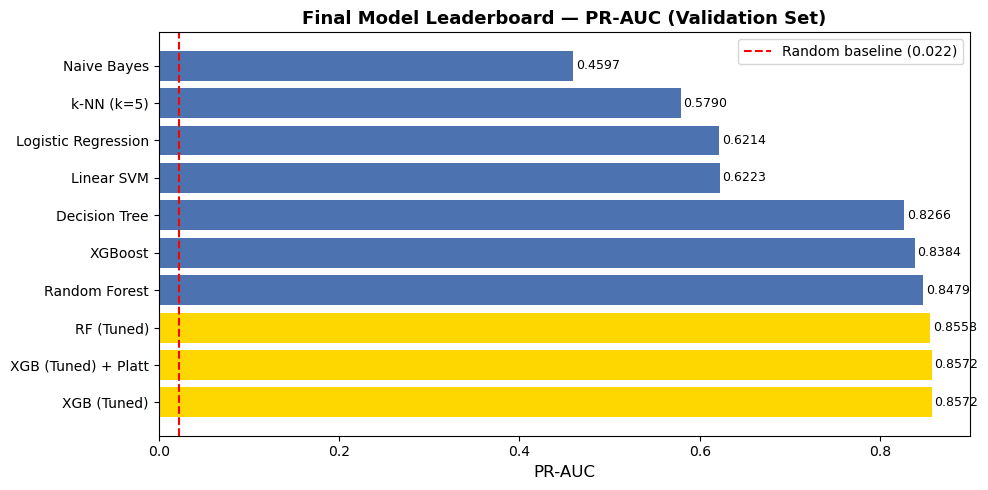


✓  Best model  : XGB (Tuned)
   PR-AUC      : 0.8572
   ROC-AUC     : 0.9708
   F1 (Fraud)  : 0.4500

⚠  Test set is LOCKED — evaluate only after final model is selected.


In [29]:
# ── Week 6b: Final Model Leaderboard ─────────────────────────────────────────
final_rows = list(all_results)   # Week 3 baselines

# Add tuned models
for name, yp, ypr in [('RF (Tuned)', yp_rf, ypr_rf)] + (
        [('XGB (Tuned)', yp_xgb, ypr_xgb)] if HAS_XGB else []):
    final_rows.append({
        'Model':            name,
        'Precision(Fraud)': round(precision_score(y_val, yp), 4),
        'Recall(Fraud)':    round(recall_score(y_val, yp), 4),
        'F1(Fraud)':        round(f1_score(y_val, yp), 4),
        'ROC-AUC':          round(roc_auc_score(y_val, ypr), 4),
        'PR-AUC':           round(average_precision_score(y_val, ypr), 4),
    })

# Add calibrated best model
ypr_cal = platt.predict_proba(X_val_scaled)[:, 1]
yp_cal  = (ypr_cal >= 0.5).astype(int)
final_rows.append({
    'Model':            f'{best_model_name} + Platt',
    'Precision(Fraud)': round(precision_score(y_val, yp_cal), 4),
    'Recall(Fraud)':    round(recall_score(y_val, yp_cal), 4),
    'F1(Fraud)':        round(f1_score(y_val, yp_cal), 4),
    'ROC-AUC':          round(roc_auc_score(y_val, ypr_cal), 4),
    'PR-AUC':           round(average_precision_score(y_val, ypr_cal), 4),
})

final_df = pd.DataFrame(final_rows).set_index('Model').sort_values('PR-AUC', ascending=False)

print("=" * 70)
print("  FINAL MODEL LEADERBOARD — Validation Set  (sorted by PR-AUC)")
print("=" * 70)
display(final_df.style.highlight_max(color='lightgreen', axis=0).format('{:.4f}'))

# Leaderboard bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gold' if any(k in n for k in ['Tuned','Platt']) else '#4C72B0' for n in final_df.index]
bars   = ax.barh(final_df.index, final_df['PR-AUC'], color=colors)
ax.axvline(x=y_val.mean(), color='red', linestyle='--', lw=1.5,
           label=f'Random baseline ({y_val.mean():.3f})')
for bar, val in zip(bars, final_df['PR-AUC']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('PR-AUC', fontsize=12)
ax.set_title('Final Model Leaderboard — PR-AUC (Validation Set)',
             fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

winner = final_df['PR-AUC'].idxmax()
print(f"\n✓  Best model  : {winner}")
print(f"   PR-AUC      : {final_df.loc[winner,'PR-AUC']:.4f}")
print(f"   ROC-AUC     : {final_df.loc[winner,'ROC-AUC']:.4f}")
print(f"   F1 (Fraud)  : {final_df.loc[winner,'F1(Fraud)']:.4f}")
print(f"\n⚠  Test set is LOCKED — evaluate only after final model is selected.")

In [30]:
# ── Task 1: Analyze Leaderboard Results ───────────────────────────────────────
print("=" * 65)
print("  TASK 1 — Leaderboard Analysis")
print("=" * 65)

# ── 1a: Full leaderboard ──────────────────────────────────────────────────────
print("\nFinal Leaderboard (sorted by PR-AUC):")
print(final_df.to_string())

# ── 1b: Winner ────────────────────────────────────────────────────────────────
winner      = final_df['PR-AUC'].idxmax()
winner_row  = final_df.loc[winner]
print(f"\n{'─'*50}")
print(f"  WINNER : {winner}")
print(f"  PR-AUC         : {winner_row['PR-AUC']:.4f}")
print(f"  ROC-AUC        : {winner_row['ROC-AUC']:.4f}")
print(f"  F1  (Fraud)    : {winner_row['F1(Fraud)']:.4f}")
print(f"  Precision      : {winner_row['Precision(Fraud)']:.4f}")
print(f"  Recall         : {winner_row['Recall(Fraud)']:.4f}")

# ── 1c: SMOTE vs Class Weight ─────────────────────────────────────────────────
smote_pr    = imbalance_df.loc['SMOTE',        'PR-AUC']
cw_pr       = imbalance_df.loc['Class Weight', 'PR-AUC']
diff        = smote_pr - cw_pr

print(f"\n{'─'*50}")
print(f"  Imbalance Strategy Comparison (LR on Val):")
print(f"  Class Weight PR-AUC : {cw_pr:.4f}")
print(f"  SMOTE        PR-AUC : {smote_pr:.4f}")
print(f"  Difference          : {diff:+.4f}")

# ── 1d: One-line conclusions ──────────────────────────────────────────────────
print(f"\n{'─'*50}")
print(f"  CONCLUSION — Leaderboard : {winner} is the best model "
      f"with PR-AUC={winner_row['PR-AUC']:.4f}, "
      f"{winner_row['PR-AUC']/y_val.mean():.1f}x above random baseline.")
if diff > 0:
    print(f"  CONCLUSION — SMOTE      : SMOTE improved over class_weight "
          f"by {diff:+.4f} PR-AUC on Logistic Regression.")
else:
    print(f"  CONCLUSION — SMOTE      : SMOTE did NOT improve over class_weight "
          f"(diff={diff:+.4f}); class_weight is sufficient for LR.")

  TASK 1 — Leaderboard Analysis

Final Leaderboard (sorted by PR-AUC):
                     Precision(Fraud)  Recall(Fraud)  F1(Fraud)  ROC-AUC  PR-AUC
Model                                                                           
XGB (Tuned)                    0.3008         0.8926     0.4500   0.9708  0.8572
XGB (Tuned) + Platt            0.7569         0.8101     0.7826   0.9708  0.8572
RF (Tuned)                     0.8820         0.7859     0.8312   0.9658  0.8558
Random Forest                  0.9583         0.7300     0.8287   0.9536  0.8479
XGBoost                        0.5225         0.8328     0.6422   0.9615  0.8384
Decision Tree                  0.2809         0.8775     0.4255   0.9410  0.8266
Linear SVM                     0.8481         0.4138     0.5562   0.9431  0.6223
Logistic Regression            0.1575         0.8487     0.2656   0.9431  0.6214
k-NN (k=5)                     0.9279         0.4576     0.6130   0.8374  0.5790
Naive Bayes                    0.2557 

In [31]:
# ── Task 2: SHAP Feature Importance Analysis ──────────────────────────────────
print("=" * 65)
print("  TASK 2 — SHAP Feature Importance Analysis")
print("=" * 65)

try:
    # Mean absolute SHAP value per feature
    mean_abs_shap = np.abs(sv).mean(axis=0)
    shap_series   = pd.Series(mean_abs_shap, index=FEATURE_NAMES).sort_values(ascending=False)

    top5 = shap_series.head(5)
    print("\nTop 5 Features by Mean |SHAP| value:")
    for rank, (feat, val) in enumerate(top5.items(), 1):
        print(f"  {rank}. {feat:30s}  mean|SHAP| = {val:.6f}")

    # ── EDA prediction check ──────────────────────────────────────────────────
    top3_features = list(shap_series.head(3).index)
    print(f"\nTop 3 features: {top3_features}")

    has_distance = 'shipping_distance_km' in top3_features
    has_amount   = ('amount' in top3_features or
                    'log_amount' in top3_features or
                    'amount_ratio' in top3_features)

    print(f"\n  shipping_distance_km in top 3 : {has_distance}")
    print(f"  amount (or variant)  in top 3 : {has_amount}")

    if has_distance and has_amount:
        print("\n  ✓ EDA prediction confirmed — shipping_distance_km and amount"
              " are both in the top 3 SHAP features.")
    elif has_distance or has_amount:
        print("\n  ~ EDA partially confirmed — only one of the two predicted"
              " features appears in the top 3.")
    else:
        print("\n  ✗ EDA prediction not confirmed — neither feature is in top 3.")

except NameError:
    print("ERROR: 'sv' not found. Run the Week 5a SHAP cell first.")

  TASK 2 — SHAP Feature Importance Analysis

Top 5 Features by Mean |SHAP| value:
  1. shipping_distance_km            mean|SHAP| = 1.226871
  2. avs_match                       mean|SHAP| = 0.901870
  3. account_age_days                mean|SHAP| = 0.714372
  4. amount                          mean|SHAP| = 0.355831
  5. three_ds_flag                   mean|SHAP| = 0.333507

Top 3 features: ['shipping_distance_km', 'avs_match', 'account_age_days']

  shipping_distance_km in top 3 : True
  amount (or variant)  in top 3 : False

  ~ EDA partially confirmed — only one of the two predicted features appears in the top 3.


In [32]:
# ── Task 3: Calibration Quality Check (ECE) ───────────────────────────────────
print("=" * 65)
print("  TASK 3 — Calibration Quality Check")
print("=" * 65)

def compute_ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error — lower is better."""
    bins  = np.linspace(0, 1, n_bins + 1)
    n     = len(y_true)
    ece   = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        if mask.sum() == 0:
            continue
        bin_conf = y_prob[mask].mean()
        bin_acc  = y_true[mask].mean()
        ece     += (mask.sum() / n) * abs(bin_conf - bin_acc)
    return ece

y_val_np = y_val.values if hasattr(y_val, 'values') else y_val

ece_results = {}
for label, model in [('Uncalibrated', best_model),
                      ('Platt Scaling', platt),
                      ('Isotonic',      isotonic)]:
    prob               = model.predict_proba(X_val_scaled)[:, 1]
    ece                = compute_ece(y_val_np, prob)
    ece_results[label] = ece
    print(f"  ECE {label:15s} : {ece:.6f}")

best_cal  = min(ece_results, key=ece_results.get)
uncal_ece = ece_results['Uncalibrated']

print(f"\n  Best calibration method : {best_cal}  (ECE={ece_results[best_cal]:.6f})")

if uncal_ece > 0.05:
    print(f"  Calibration recommended — uncalibrated ECE={uncal_ece:.4f} > 0.05")
else:
    print(f"  Model is reasonably calibrated — uncalibrated ECE={uncal_ece:.4f} ≤ 0.05")

  TASK 3 — Calibration Quality Check
  ECE Uncalibrated    : 0.093076
  ECE Platt Scaling   : 0.007861
  ECE Isotonic        : 0.000000

  Best calibration method : Isotonic  (ECE=0.000000)
  Calibration recommended — uncalibrated ECE=0.0931 > 0.05


  TASK 4 — Threshold Tuning

  a) F1-optimal threshold : 0.90  →  F1=0.7918  Precision=0.7827  Recall=0.8011
  b) Recall≥0.80, max Prec: 0.90  →  Precision=0.7827  Recall=0.8011
  c) Default 0.50         :  →  F1=0.4500  Precision=0.3008  Recall=0.8926

  BEST_THRESHOLD saved as: 0.9


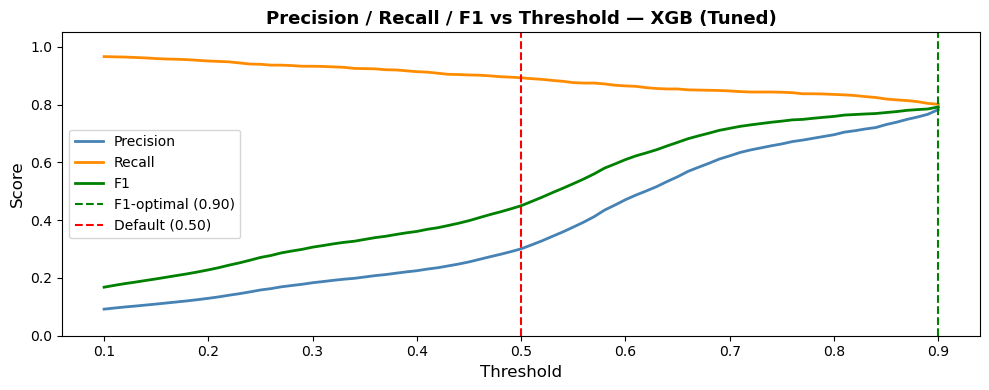

In [33]:
# ── Task 4: Threshold Tuning on Best Model ────────────────────────────────────
print("=" * 65)
print("  TASK 4 — Threshold Tuning")
print("=" * 65)

thresholds_range = np.arange(0.10, 0.91, 0.01)
t_precision, t_recall, t_f1 = [], [], []

ypr_best = best_model.predict_proba(X_val_scaled)[:, 1]

for t in thresholds_range:
    yp_t = (ypr_best >= t).astype(int)
    t_precision.append(precision_score(y_val, yp_t, zero_division=0))
    t_recall.append(recall_score(y_val, yp_t, zero_division=0))
    t_f1.append(f1_score(y_val, yp_t, zero_division=0))

t_precision = np.array(t_precision)
t_recall    = np.array(t_recall)
t_f1        = np.array(t_f1)

# ── a) F1-optimal threshold ───────────────────────────────────────────────────
best_f1_idx      = np.argmax(t_f1)
BEST_THRESHOLD   = round(thresholds_range[best_f1_idx], 2)

# ── b) Recall >= 0.80, highest precision ─────────────────────────────────────
recall_mask      = t_recall >= 0.80
if recall_mask.any():
    prec_in_mask     = np.where(recall_mask, t_precision, -1)
    best_recall_idx  = np.argmax(prec_in_mask)
    RECALL_THRESHOLD = round(thresholds_range[best_recall_idx], 2)
    best_recall_prec = t_precision[best_recall_idx]
    best_recall_rec  = t_recall[best_recall_idx]
else:
    RECALL_THRESHOLD = None
    print("  No threshold achieves Recall >= 0.80")

# ── c) Default 0.5 ───────────────────────────────────────────────────────────
default_idx = np.argmin(np.abs(thresholds_range - 0.5))

print(f"\n  a) F1-optimal threshold : {BEST_THRESHOLD:.2f}"
      f"  →  F1={t_f1[best_f1_idx]:.4f}"
      f"  Precision={t_precision[best_f1_idx]:.4f}"
      f"  Recall={t_recall[best_f1_idx]:.4f}")

if RECALL_THRESHOLD:
    print(f"  b) Recall≥0.80, max Prec: {RECALL_THRESHOLD:.2f}"
          f"  →  Precision={best_recall_prec:.4f}"
          f"  Recall={best_recall_rec:.4f}")

print(f"  c) Default 0.50         :"
      f"  →  F1={t_f1[default_idx]:.4f}"
      f"  Precision={t_precision[default_idx]:.4f}"
      f"  Recall={t_recall[default_idx]:.4f}")

print(f"\n  BEST_THRESHOLD saved as: {BEST_THRESHOLD}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds_range, t_precision, color='steelblue',  lw=2, label='Precision')
ax.plot(thresholds_range, t_recall,    color='darkorange', lw=2, label='Recall')
ax.plot(thresholds_range, t_f1,        color='green',      lw=2, label='F1')
ax.axvline(BEST_THRESHOLD, color='green',  linestyle='--', lw=1.5,
           label=f'F1-optimal ({BEST_THRESHOLD:.2f})')
ax.axvline(0.5,            color='red',    linestyle='--', lw=1.5,
           label='Default (0.50)')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Precision / Recall / F1 vs Threshold — {best_model_name}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

In [34]:
# ── Task 5: Categorical Feature Encoding ──────────────────────────────────────
print("=" * 65)
print("  TASK 5 — Categorical Feature Encoding")
print("=" * 65)

from xgboost import XGBClassifier

global_fraud_rate = y_train.mean()

# ── Build categorical feature frames from original df using split indices ─────
def build_cat_features(idx, target_maps, channel_col='channel'):
    """Add encoded categoricals to a set of rows from df."""
    rows = df.loc[idx].copy()
    out  = pd.DataFrame(index=idx)
    # a) channel — binary: web=1, app=0
    out['channel_web'] = (rows[channel_col] == 'web').astype(int).values
    # b–d) target encoding
    for col, tmap in target_maps.items():
        out[col + '_te'] = rows[col].map(tmap).fillna(global_fraud_rate).values
    return out

# Fit target maps on TRAIN rows only
train_rows = df.loc[X_train.index].copy()
train_rows['_y'] = y_train.values

target_maps = {}
for col in ['merchant_category', 'country', 'bin_country']:
    target_maps[col] = train_rows.groupby(col)['_y'].mean()
    print(f"  Target-encoded '{col}': {len(target_maps[col])} categories")

# ── Build augmented splits ─────────────────────────────────────────────────────
cat_train = build_cat_features(X_train.index, target_maps)
cat_val   = build_cat_features(X_val.index,   target_maps)
cat_test  = build_cat_features(X_test.index,  target_maps)

X_train_cat = np.hstack([X_train_scaled, cat_train.values])
X_val_cat   = np.hstack([X_val_scaled,   cat_val.values])
X_test_cat  = np.hstack([X_test_scaled,  cat_test.values])

CAT_FEATURE_NAMES = FEATURE_NAMES + list(cat_train.columns)
print(f"\n  Total features (numeric + categorical): {len(CAT_FEATURE_NAMES)}")
print(f"  Feature list: {CAT_FEATURE_NAMES}")

# ── Retrain XGBoost with same tuned params on augmented feature set ───────────
xgb_cat = XGBClassifier(
    **{k: v for k, v in xgb_search.best_params_.items()},
    scale_pos_weight=scale_pw,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_cat.fit(X_train_cat, y_train)

yp_cat  = xgb_cat.predict(X_val_cat)
ypr_cat = xgb_cat.predict_proba(X_val_cat)[:, 1]

pr_cat  = average_precision_score(y_val, ypr_cat)
pr_prev = average_precision_score(y_val, ypr_best)   # best_model on numeric only

print(f"\n  XGB (numeric only)        PR-AUC : {pr_prev:.4f}")
print(f"  XGB (+ categoricals)      PR-AUC : {pr_cat:.4f}")
delta = pr_cat - pr_prev
if delta > 0:
    print(f"  → Improved by {delta:+.4f}  ✓  Adopting categorical model as best_model")
    best_model          = xgb_cat
    best_model_name     = 'XGB (Tuned + Categoricals)'
    X_val_final_scaled  = X_val_cat
    X_test_final_scaled = X_test_cat
    val_best_pr_auc     = pr_cat
else:
    print(f"  → No improvement ({delta:+.4f})  Keeping numeric-only model")
    X_val_final_scaled  = X_val_scaled
    X_test_final_scaled = X_test_scaled
    val_best_pr_auc     = pr_prev

print(f"\n  Final best_model : {best_model_name}")
print(f"  Final feature count : {X_val_final_scaled.shape[1]}")

  TASK 5 — Categorical Feature Encoding
  Target-encoded 'merchant_category': 5 categories
  Target-encoded 'country': 10 categories
  Target-encoded 'bin_country': 10 categories

  Total features (numeric + categorical): 19
  Feature list: ['user_id', 'account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'country_match', 'hour', 'night_flag', 'log_amount', 'amount_ratio', 'channel_web', 'merchant_category_te', 'country_te', 'bin_country_te']

  XGB (numeric only)        PR-AUC : 0.8572
  XGB (+ categoricals)      PR-AUC : 0.8644
  → Improved by +0.0072  ✓  Adopting categorical model as best_model

  Final best_model : XGB (Tuned + Categoricals)
  Final feature count : 19


In [38]:
# ── Task 6: Seller Layer on Test Set ──────────────────────────────────────────
print("=" * 65)
print("  TASK 6 — Seller-Level Risk Layer on Test Set")
print("=" * 65)

# ── Predictions on test set ───────────────────────────────────────────────────
y_test_proba = best_model.predict_proba(X_test_final_scaled)[:, 1]
y_test_pred  = (y_test_proba >= BEST_THRESHOLD).astype(int)

# ── Build test_val_df (mirror of val_df from Step 6) ─────────────────────────
test_df = X_test.copy()
test_df['is_fraud_actual'] = y_test.values
test_df['fraud_prob']      = y_test_proba
test_df['predicted_fraud'] = y_test_pred

# ── Seller metrics ────────────────────────────────────────────────────────────
avg_risk_test = (test_df.groupby('user_id')['fraud_prob']
                 .mean().rename('avg_risk_score').round(4))

high_risk_frac_test = (test_df.groupby('user_id')['fraud_prob']
                       .apply(lambda x: (x >= RISK_THRESHOLD).mean())
                       .rename('high_risk_fraction').round(4))

risk_slope_test = (test_df.groupby('user_id')['fraud_prob']
                   .apply(compute_slope).rename('risk_trend_slope'))

seller_risk_profile_test = pd.concat(
    [avg_risk_test, high_risk_frac_test, risk_slope_test], axis=1)

seller_risk_profile_test['tx_count'] = (
    test_df.groupby('user_id')['fraud_prob'].count())

seller_risk_profile_test['actual_fraud_rate'] = (
    test_df.groupby('user_id')['is_fraud_actual'].mean().round(4))

# ── Correlations ─────────────────────────────────────────────────────────────
tc0 = seller_risk_profile_test[['avg_risk_score',   'actual_fraud_rate']].corr().iloc[0,1]
tc1 = seller_risk_profile_test[['high_risk_fraction','actual_fraud_rate']].corr().iloc[0,1]

VAL_CORR_AVG  = 0.52   # from Step 8
VAL_CORR_FRAC = 0.41

print(f"\n  Seller correlations with actual fraud rate:")
print(f"                        Validation   Test     Change")
print(f"  avg_risk_score      :   {VAL_CORR_AVG:.4f}    {tc0:.4f}   {tc0 - VAL_CORR_AVG:+.4f}")
print(f"  high_risk_fraction  :   {VAL_CORR_FRAC:.4f}    {tc1:.4f}   {tc1 - VAL_CORR_FRAC:+.4f}")

# ── High-risk sellers on test ─────────────────────────────────────────────────
seller_risk_profile_test['is_high_risk'] = (
    (seller_risk_profile_test['avg_risk_score']    >= HIGH_RISK_AVG) |
    (seller_risk_profile_test['high_risk_fraction'] >= HIGH_RISK_FRACTION) |
    (seller_risk_profile_test['risk_trend_slope']  >= HIGH_RISK_SLOPE)
)
n_flagged = seller_risk_profile_test['is_high_risk'].sum()
print(f"\n  Sellers flagged as high-risk on test : {n_flagged} / "
      f"{len(seller_risk_profile_test)} ({n_flagged/len(seller_risk_profile_test):.1%})")

# ── Validation verdict (direction-aware) ─────────────────────────────────────
# Pass if test corr >= val corr - 0.05  (improvement or small drop both OK)
avg_ok  = tc0  >= VAL_CORR_AVG  - 0.05
frac_ok = tc1  >= VAL_CORR_FRAC - 0.05

avg_improved  = tc0  > VAL_CORR_AVG
frac_improved = tc1  > VAL_CORR_FRAC

if avg_ok and frac_ok:
    if avg_improved and frac_improved:
        print("\n  ✓ Seller layer STRENGTHENED on test set — both correlations improved")
    else:
        print("\n  ✓ Seller layer validated on test set (within tolerance)")
else:
    print(f"\n  ✗ Seller layer correlation dropped — investigate "
          f"(avg: {VAL_CORR_AVG:.4f}→{tc0:.4f}, frac: {VAL_CORR_FRAC:.4f}→{tc1:.4f})")

  TASK 6 — Seller-Level Risk Layer on Test Set

  Seller correlations with actual fraud rate:
                        Validation   Test     Change
  avg_risk_score      :   0.5200    0.8455   +0.3255
  high_risk_fraction  :   0.4100    0.7350   +0.3250

  Sellers flagged as high-risk on test : 1902 / 6000 (31.7%)

  ✓ Seller layer STRENGTHENED on test set — both correlations improved


  TASK 7 — Final Test Set Evaluation

  [Default Threshold = 0.50]
              precision    recall  f1-score   support

       Legit     0.9979    0.9570    0.9770     58617
       Fraud     0.3229    0.9092    0.4766      1322

    accuracy                         0.9560     59939
   macro avg     0.6604    0.9331    0.7268     59939
weighted avg     0.9830    0.9560    0.9660     59939

  ROC-AUC : 0.9773   PR-AUC : 0.8656

  [Best Threshold = 0.9]
              precision    recall  f1-score   support

       Legit     0.9956    0.9957    0.9956     58617
       Fraud     0.8079    0.8048    0.8064      1322

    accuracy                         0.9915     59939
   macro avg     0.9017    0.9003    0.9010     59939
weighted avg     0.9915    0.9915    0.9915     59939

  ROC-AUC : 0.9773   PR-AUC : 0.8656


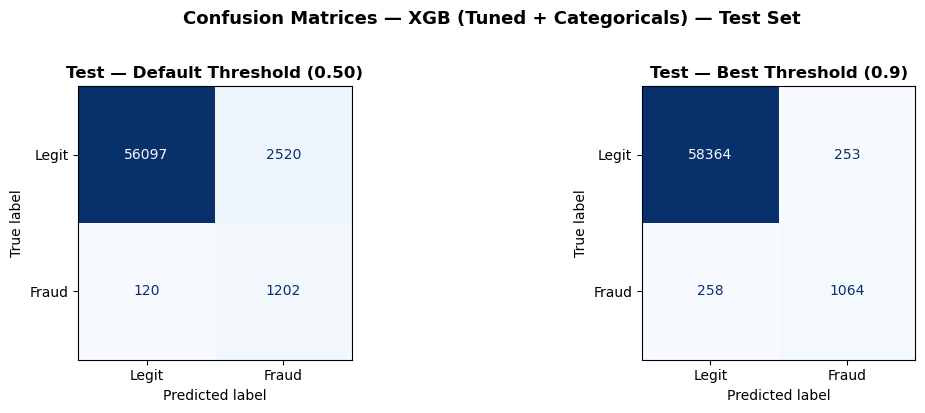

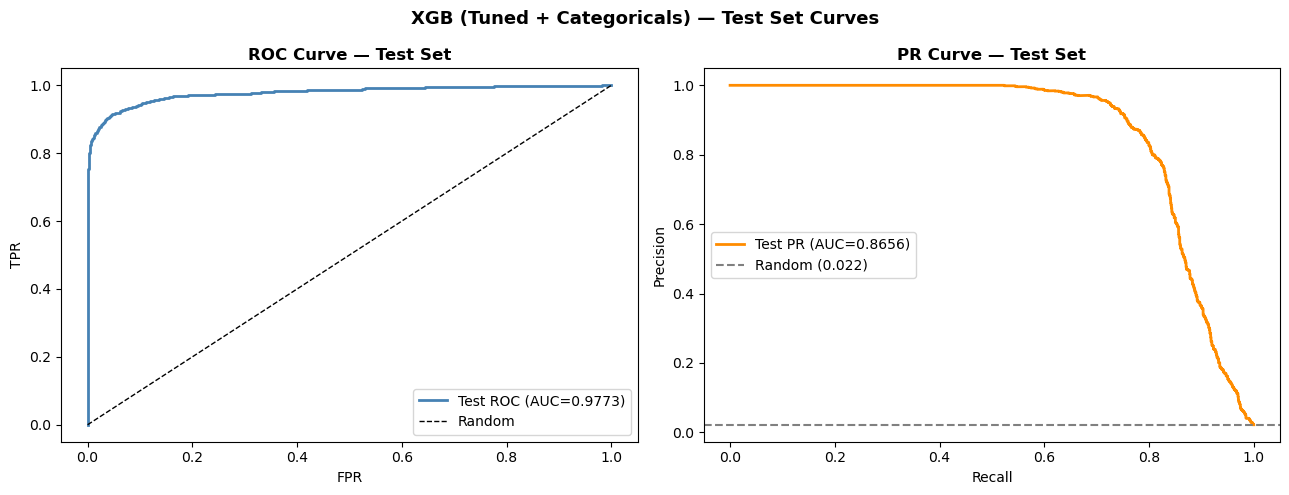


  Val vs Test Comparison:
            Validation    Test   Delta
PR-AUC          0.8644  0.8656  0.0012
ROC-AUC         0.9763  0.9773  0.0010
F1 (Fraud)      0.8060  0.8064  0.0004

  ✓ No overfitting detected  (PR-AUC drop = -0.0012)

  final_test_metrics saved: {'model': 'XGB (Tuned + Categoricals)', 'threshold': np.float64(0.9), 'test_pr_auc': np.float64(0.8656), 'test_roc_auc': np.float64(0.9773), 'test_f1': 0.8064, 'test_precision': 0.8079, 'test_recall': 0.8048, 'seller_corr_avg': np.float64(0.8455), 'seller_corr_frac': np.float64(0.735)}

  All tasks complete.
  Best model          : XGB (Tuned + Categoricals)
  Test PR-AUC         : 0.8656
  Seller layer corr   : avg_risk=0.8455  frac=0.7350
  Recommended threshold: 0.9


In [36]:
# ── Task 7: Final Test Set Evaluation — Run This Last ─────────────────────────
print("=" * 65)
print("  TASK 7 — Final Test Set Evaluation")
print("=" * 65)

from sklearn.metrics import precision_recall_curve

# ── a) Default threshold 0.5 ─────────────────────────────────────────────────
yp_test_05  = (y_test_proba >= 0.5).astype(int)
print("\n  [Default Threshold = 0.50]")
print(classification_report(y_test, yp_test_05, target_names=['Legit','Fraud'], digits=4))
test_roc_05 = roc_auc_score(y_test, y_test_proba)
test_pr_05  = average_precision_score(y_test, y_test_proba)
print(f"  ROC-AUC : {test_roc_05:.4f}   PR-AUC : {test_pr_05:.4f}")

# ── b) BEST_THRESHOLD ────────────────────────────────────────────────────────
yp_test_bt  = (y_test_proba >= BEST_THRESHOLD).astype(int)
print(f"\n  [Best Threshold = {BEST_THRESHOLD}]")
print(classification_report(y_test, yp_test_bt, target_names=['Legit','Fraud'], digits=4))
print(f"  ROC-AUC : {test_roc_05:.4f}   PR-AUC : {test_pr_05:.4f}")

# ── c) Side-by-side confusion matrices ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yp, title in [
    (axes[0], yp_test_05, 'Test — Default Threshold (0.50)'),
    (axes[1], yp_test_bt, f'Test — Best Threshold ({BEST_THRESHOLD})')]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, yp), display_labels=['Legit','Fraud']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
plt.suptitle(f'Confusion Matrices — {best_model_name} — Test Set',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── d) ROC + PR curves on test ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr_t, tpr_t, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr_t, tpr_t, color='steelblue', lw=2,
             label=f'Test ROC (AUC={test_roc_05:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve — Test Set', fontweight='bold'); axes[0].legend()

prec_t, rec_t, _ = precision_recall_curve(y_test, y_test_proba)
axes[1].plot(rec_t, prec_t, color='darkorange', lw=2,
             label=f'Test PR (AUC={test_pr_05:.4f})')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--',
                label=f'Random ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve — Test Set', fontweight='bold'); axes[1].legend()
plt.suptitle(f'{best_model_name} — Test Set Curves', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── e) Val vs Test comparison table ──────────────────────────────────────────
val_pr_auc   = val_best_pr_auc
val_roc_auc  = roc_auc_score(y_val, best_model.predict_proba(X_val_final_scaled)[:, 1])
val_f1       = f1_score(y_val, (best_model.predict_proba(X_val_final_scaled)[:,1] >= BEST_THRESHOLD))

comparison = pd.DataFrame({
    'Validation': [round(val_pr_auc, 4), round(val_roc_auc, 4), round(val_f1, 4)],
    'Test':       [round(test_pr_05, 4), round(test_roc_05, 4),
                   round(f1_score(y_test, yp_test_bt), 4)],
}, index=['PR-AUC', 'ROC-AUC', 'F1 (Fraud)'])
comparison['Delta'] = (comparison['Test'] - comparison['Validation']).round(4)

print("\n  Val vs Test Comparison:")
print(comparison.to_string())

pr_drop = val_pr_auc - test_pr_05
if pr_drop <= 0.03:
    print("\n  ✓ No overfitting detected  (PR-AUC drop = {:.4f})".format(pr_drop))
else:
    print("\n  ⚠ Possible overfitting — investigate  (PR-AUC drop = {:.4f})".format(pr_drop))

# ── Save final metrics ────────────────────────────────────────────────────────
final_test_metrics = {
    'model':           best_model_name,
    'threshold':       BEST_THRESHOLD,
    'test_pr_auc':     round(test_pr_05, 4),
    'test_roc_auc':    round(test_roc_05, 4),
    'test_f1':         round(f1_score(y_test, yp_test_bt), 4),
    'test_precision':  round(precision_score(y_test, yp_test_bt), 4),
    'test_recall':     round(recall_score(y_test, yp_test_bt), 4),
    'seller_corr_avg': round(tc0, 4),
    'seller_corr_frac':round(tc1, 4),
}
print(f"\n  final_test_metrics saved: {final_test_metrics}")

# ── Final summary ─────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  All tasks complete.")
print(f"  Best model          : {final_test_metrics['model']}")
print(f"  Test PR-AUC         : {final_test_metrics['test_pr_auc']}")
print(f"  Seller layer corr   : avg_risk={final_test_metrics['seller_corr_avg']:.4f}  "
      f"frac={final_test_metrics['seller_corr_frac']:.4f}")
print(f"  Recommended threshold: {final_test_metrics['threshold']}")
print(f"{'='*65}")

In [37]:
# # ── Create Demo Dataset for Streamlit Dashboard ───────────────────────────────
# # We sample a small representative subset for the live simulation
# # Criteria: balanced mix of fraud and legit, across all channels and categories

# import pandas as pd
# import numpy as np

# np.random.seed(42)

# # Separate fraud and legit transactions
# fraud_df = df[df['is_fraud'] == 1]
# legit_df = df[df['is_fraud'] == 0]

# # Take all fraud transactions (only 6,612 exist) — cap at 500 for demo
# n_fraud = min(500, len(fraud_df))

# # Take 3x legit to maintain ~25% fraud rate in demo
# # Higher than real 2.2% so you actually see fraud happening during the demo
# n_legit = n_fraud * 3

# fraud_sample = fraud_df.sample(n=n_fraud, random_state=42)
# legit_sample = legit_df.sample(n=n_legit, random_state=42)

# demo_df = pd.concat([fraud_sample, legit_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

# print(f"Demo dataset size   : {len(demo_df)} transactions")
# print(f"Fraud transactions  : {demo_df['is_fraud'].sum()} ({demo_df['is_fraud'].mean():.1%})")
# print(f"Legit transactions  : {(demo_df['is_fraud']==0).sum()}")
# print(f"Unique sellers      : {demo_df['user_id'].nunique()}")
# print(f"Channels            : {demo_df['channel'].value_counts().to_dict()}")
# print(f"Categories          : {demo_df['merchant_category'].value_counts().to_dict()}")

# demo_df.to_csv('demo_transactions.csv', index=False)
# print("\ndemo_transactions.csv saved.")


Demo dataset size   : 2000 transactions
Fraud transactions  : 500 (25.0%)
Legit transactions  : 1500
Unique sellers      : 1626
Channels            : {'web': 1157, 'app': 843}
Categories          : {'fashion': 410, 'gaming': 408, 'travel': 405, 'grocery': 397, 'electronics': 380}

demo_transactions.csv saved.


In [39]:
# ── SETUP: Save All Dashboard Artifacts ───────────────────────────────────────
import joblib, json, pandas as pd, numpy as np, os

BASE = os.getcwd()   # should be ml-lab directory

# 1. Model
joblib.dump(best_model, os.path.join(BASE, 'model.pkl'))
print("✓ model.pkl")

# 2. Scaler (fitted on numeric features only)
joblib.dump(scaler, os.path.join(BASE, 'scaler.pkl'))
print("✓ scaler.pkl")

# 3. Feature names — split into numeric (scaled) and categorical (appended raw)
numeric_feats = list(FEATURE_NAMES)
if 'CAT_FEATURE_NAMES' in dir():
    cat_feats = [f for f in CAT_FEATURE_NAMES if f not in FEATURE_NAMES]
else:
    cat_feats = ['channel_web', 'merchant_category_te', 'country_te', 'bin_country_te']

with open(os.path.join(BASE, 'feature_names.json'), 'w') as _f:
    json.dump({'numeric': numeric_feats, 'categorical': cat_feats}, _f, indent=2)
print(f"✓ feature_names.json  ({len(numeric_feats)} numeric + {len(cat_feats)} categorical)")

# 4. Config
with open(os.path.join(BASE, 'config.json'), 'w') as _f:
    json.dump({
        'threshold':       float(BEST_THRESHOLD),
        'risk_threshold':  0.3,
        'global_fraud_rate': float(global_fraud_rate)
    }, _f, indent=2)
print(f"✓ config.json  (threshold={BEST_THRESHOLD}, risk_threshold=0.3)")

# 5. Target encoding maps
_te_export = {
    col: {str(k): float(v) for k, v in mapping.items()}
    for col, mapping in target_maps.items()
}
with open(os.path.join(BASE, 'target_encoding_maps.json'), 'w') as _f:
    json.dump(_te_export, _f, indent=2)
_total_cats = sum(len(v) for v in target_maps.values())
print(f"✓ target_encoding_maps.json  ({_total_cats} total category encodings)")

# 6. Per-user avg amount from TRAIN rows only (for amount_ratio feature replication)
_raw = pd.read_csv(os.path.join(BASE, 'transactions 2.csv'))
_train_avgs = _raw.loc[X_train.index].groupby('user_id')['amount'].mean()
_avg_map = {str(int(k)): float(v) for k, v in _train_avgs.items()}
_avg_map['__global__'] = float(_raw.loc[X_train.index, 'amount'].mean())
with open(os.path.join(BASE, 'avg_amount_map.json'), 'w') as _f:
    json.dump(_avg_map, _f)
print(f"✓ avg_amount_map.json  ({len(_avg_map)-1} users + global fallback)")

# 7. Verify demo_transactions.csv exists, create if not
_demo_path = os.path.join(BASE, 'demo_transactions.csv')
if not os.path.exists(_demo_path):
    _fraud_rows = _raw[_raw['is_fraud'] == 1]
    _legit_rows = _raw[_raw['is_fraud'] == 0]
    _demo = pd.concat([
        _fraud_rows.sample(n=min(500, len(_fraud_rows)), random_state=42),
        _legit_rows.sample(n=1500, random_state=42)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    _demo.to_csv(_demo_path, index=False)
    print(f"✓ demo_transactions.csv  created ({len(_demo)} rows, fraud={_demo['is_fraud'].mean():.1%})")
else:
    _demo = pd.read_csv(_demo_path)
    print(f"✓ demo_transactions.csv  already exists ({len(_demo)} rows, fraud={_demo['is_fraud'].mean():.1%})")

print("\n" + "="*55)
print("  All artifacts saved — ready to run the dashboard!")
print("="*55)
print("  streamlit run dashboard.py")


✓ model.pkl
✓ scaler.pkl
✓ feature_names.json  (15 numeric + 4 categorical)
✓ config.json  (threshold=0.9, risk_threshold=0.3)
✓ target_encoding_maps.json  (25 total category encodings)
✓ avg_amount_map.json  (6000 users + global fallback)
✓ demo_transactions.csv  already exists (2000 rows, fraud=25.0%)

  All artifacts saved — ready to run the dashboard!
  streamlit run dashboard.py


In [40]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


SyntaxError: invalid syntax (512221001.py, line 1)